### General Setup

In [180]:
import math
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from graph import Graph
from graph_algorithms import get_degree_distribution, get_diameter

csv_file_a = "./enhanced_box_office_data(2000-2024).csv"
csv_file_b = "./tmdb_5000_movies.csv"

### Preprocessing Enhanced Box Office Data Set

In [181]:
# Load movie data
movie_data_A = pd.read_csv(csv_file_a)

# =================================================================================================
# MISSING/UNUSABLE ROWS
# =================================================================================================

# Remove rows with null values (usually, specific rows will be missing many of the values, as noted here: 
#   https://www.kaggle.com/code/celalngr/movie-box-office-data-analysis-and-preprocessing/notebook#Visualization-of-Missing-Data)
movie_data_A.dropna(inplace=True)
movie_data_A.drop(columns=["Rank"], inplace=True)

# =================================================================================================
# RATINGS
# =================================================================================================

# Remove "/10" from ratings and convert to float
movie_data_A['Rating'] = movie_data_A['Rating'].str.replace('/10', '', regex=True).str.strip()
movie_data_A['Rating'] = movie_data_A['Rating'].astype(float)

# =================================================================================================
# ORIGINAL LANGUAGE
# =================================================================================================

# Convert to boolean: 1 if English, 0 otherwise
movie_data_A['Original_Language'] = (movie_data_A['Original_Language'] == 'en').astype(int)

# =================================================================================================
# YEAR
# =================================================================================================

# Remove '20' prefix from years
movie_data_A['Year'] = movie_data_A['Year'] - 2000 

# =================================================================================================
# GENRES
# =================================================================================================

# Get a list of unique genres and map to index ids
movie_data_A["Genres"] = movie_data_A["Genres"].astype(str).str.split(pat=',').apply(lambda list: [genre.strip() for genre in list])
genres = set(movie_data_A["Genres"].explode())
genre_to_idx = dict(zip(sorted(genres), range(len(genres))))
idx_to_genre = dict(zip(range(len(genres)), sorted(genres)))

# Convert genre lists into multi-hot vectors (0/1 boolean vectors for categories)
genre_dummies = movie_data_A["Genres"].explode().str.get_dummies().groupby(level=0).max()
genre_dummies = genre_dummies[sorted(genre_dummies.columns)]
movie_data_A["Genres"] = genre_dummies.values.tolist()

# Display useful variables
# print(f"Genre set       : {genres}")
# print(f"Genre-index map : {genre_to_idx}")
# print(f"Index-genre map : {idx_to_genre}")

# =================================================================================================
# PRODUCTION COUNTRIES
# =================================================================================================
top_production_country_count = 20   # Used to simplify problem by lowering dimensionality-- In other words, only create categories for the top n countries
placeholder = "Other"               # Used to replace country names not in the top n countries

# Get a list of top `top_production_country_count` unique countries
movie_data_A["Production_Countries"] = movie_data_A["Production_Countries"].astype(str).str.split(pat=',').apply(lambda list: [country.strip() for country in list])
top_countries = movie_data_A["Production_Countries"].explode().value_counts().head(top_production_country_count)
countries = set(top_countries.index)

# Map top countries to index ids
idx_to_country = dict(zip(range(len(top_countries.index)), list(top_countries.index)))
country_to_idx = dict(zip(list(top_countries.index), range(len(countries))))

# Handle placeholder cases
countries.add(placeholder)
idx_to_country[top_production_country_count] = placeholder
country_to_idx[placeholder] = top_production_country_count

# Convert country lists into multi-hot vectors
country_dummies = movie_data_A["Production_Countries"].explode()
country_dummies = country_dummies.where(country_dummies.isin(countries), other=placeholder)
country_dummies = country_dummies.str.get_dummies().groupby(level=0).max()
country_dummies = country_dummies[sorted(country_dummies.columns, key=lambda x: country_to_idx[f"{x}"])]
movie_data_A["Production_Countries"] = country_dummies.values.tolist()

# # Display useful variables
# print(f"Production Country set : {countries}")
# print(f"Country-index map      : {country_to_idx}")
# print(f"Index-country map      : {idx_to_country}")
# display(movie_data_A)

### Preprocessing TMDB Data Set

In [182]:
# Load movie data
movie_data_B = pd.read_csv(csv_file_b)

# =================================================================================================
# MISSING/UNUSABLE ROWS
# =================================================================================================
movie_data_B.drop(movie_data_B[movie_data_B["status"] != "Released"].index, inplace=True)   # Ignore unreleased movies
movie_data_B.drop(movie_data_B[movie_data_B["budget"] == 0].index, inplace=True)            # Drop rows missing budget
movie_data_B = movie_data_B[["budget", "production_companies", "title"]]                    # Select desired columns
movie_data_B.dropna(inplace=True)                                                           # Drop rows missing desired values
movie_data_B.rename(columns={"title": "Release Group", "budget": "Budget", "production_companies": "Production_Companies"}, inplace=True)

# =================================================================================================
# PRODUCTION COMPANIES
# =================================================================================================
top_production_company_count = 20   # Used to simplify problem by lowering dimensionality-- In other words, only create categories for the top n companies
placeholder = "Other"               # Used to replace company names not in the top n companies

# Get a list of top `top_production_company_count` unique companies
movie_data_B["Production_Companies"] = movie_data_B["Production_Companies"].apply(json.loads).to_frame()
movie_data_B["Production_Companies"] = movie_data_B["Production_Companies"].apply(lambda entry: [company["name"].strip() for company in entry])
top_companies = movie_data_B["Production_Companies"].explode().value_counts().head(top_production_company_count)
companies = set(top_companies.index)
# print(top_companies)

# Map top companies to index ids
idx_to_company = dict(zip(range(len(top_companies.index)), list(top_companies.index)))
company_to_idx = dict(zip(list(top_companies.index), range(len(companies))))

# Handle placeholder cases
companies.add(placeholder)
idx_to_company[top_production_company_count] = placeholder
company_to_idx[placeholder] = top_production_company_count

# Convert company lists into multi-hot vectors
company_dummies = movie_data_B["Production_Companies"].explode()
company_dummies = company_dummies.where(company_dummies.isin(companies), other=placeholder)
company_dummies = company_dummies.str.get_dummies().groupby(level=0).max()
company_dummies = company_dummies[sorted(company_dummies.columns, key=lambda x: company_to_idx[f"{x}"])]
movie_data_B["Production_Companies"] = company_dummies.values.tolist()

# display(movie_data_B)

### Merging & General Changes

In [183]:
# =================================================================================================
# MERGING DATASETS
# =================================================================================================
movie_data = pd.merge(movie_data_A, movie_data_B, on="Release Group")

# =================================================================================================
# SUCCESS DEFINITION
# =================================================================================================
movie_data["Success"] = ((movie_data["$Worldwide"] - movie_data["Budget"])/ movie_data["Budget"]) > 1

# Previously:
# median_per_year = movie_data[['Year', '$Worldwide']].groupby("Year")["$Worldwide"].median()
# movie_data["Success"] = (movie_data["$Worldwide"] / movie_data["Year"].map(median_per_year)) > 1

movie_data_pre_normalized = movie_data.copy()

# =================================================================================================
# NORMALIZATION
# =================================================================================================
scaler = StandardScaler()
numeric_features = ['$Worldwide', '$Domestic', '$Foreign', 'Domestic %', 'Foreign %', 'Rating', 'Vote_Count', 'Budget']
movie_data[numeric_features] = scaler.fit_transform(movie_data[numeric_features])

# =================================================================================================
# FINAL TABLE
# =================================================================================================
display(movie_data)

,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries,Budget,Production_Companies,Success
0,Mission: Impossible II,1.810629,1.863976,-0.537209,1.679927,0.537216,0,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.446483,0.614075,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.470098,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
1,Gladiator,1.407420,1.509659,-0.474275,1.272502,0.474283,0,"[1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.214917,3.282991,1,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.022501,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",True
2,Cast Away,1.261972,2.097023,0.137078,0.733390,-0.137066,0,"[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.509792,1.626400,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.758012,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",True
3,What Women Want,1.001071,1.447072,-0.110160,0.700431,0.110171,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",-0.034100,0.006723,1,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.351106,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
4,Dinosaur,0.886933,0.870746,-0.537209,0.846114,0.537216,0,"[0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",0.085542,-0.300319,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.520961,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,Firestarter,-0.686274,-0.766380,0.604584,-0.603898,-0.604568,22,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",-1.115969,-0.697909,1,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.767886,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False
1937,The Color Purple,-0.433553,-0.115668,1.651977,-0.583561,-1.651952,23,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.793212,-0.790630,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.767886,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True
1938,Joy Ride,-0.682757,-0.725985,1.364281,-0.620799,-1.364258,23,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.212821,-0.770653,1,"[1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.605124,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False
1939,Mean Girls,-0.264503,0.035053,0.797880,-0.413934,-0.797862,24,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.933219,1.063563,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.727195,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",True


In [184]:
movie_data.iloc[0]

Release Group                                      Mission: Impossible II
$Worldwide                                                       1.810629
$Domestic                                                        1.863976
Domestic %                                                      -0.537209
$Foreign                                                         1.679927
Foreign %                                                        0.537216
Year                                                                    0
Genres                  [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Rating                                                          -0.446483
Vote_Count                                                       0.614075
Original_Language                                                       1
Production_Countries    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Budget                                                           1.470098
Production_Companies    [0, 0, 1, 0, 0

### Movie similarity

In [185]:
# Hamming similarity function for movie similarity
def hamming_similar(mhot1, mhot2, set_length, threshold):
    similar = True
    differences = 0
    for i, genre in enumerate(mhot1):
        if genre != mhot2[i]:
            differences += 1
            
    if 1 - (differences / set_length) < threshold:
        similar = False

    return similar

In [186]:
# Currently, similarity is measured by:
# - Threshold on genres
# - Release year similarity (proximity)
# - Production company similarity
# - Original language
def is_similar(movie_a, movie_b, genre_mode="JACCARD"):
    similar = True
    
    genre_jaccard_threshold = 0.6       # 25% similarity needed
    genre_hamming_threshold = 0.95      # 95% similarity => 1/20 differences allowed
    production_company_threshold = 0.1  # 0.1 -> 10% similarity => ~18/20 differences allowed-- 2 must be the same
    production_country_threshold = 0.5  # 0.95 -> 95% similarity => 1/20 differences allowed
    log_budget_threshold = 0.80
    release_year_threshold = 2

    # Genre similarity
    if genre_mode == "HAMMING":
        if not hamming_similar(movie_a["Genres"], movie_b["Genres"], len(genres), genre_hamming_threshold):
            similar = False
    elif genre_mode == "JACCARD":
        genres_a = set([idx_to_genre[i] for i, applies in enumerate(movie_a["Genres"]) if applies])
        genres_b = set([idx_to_genre[i] for i, applies in enumerate(movie_b["Genres"]) if applies])

        if len(genres_a & genres_b) / len(genres_a | genres_b) < genre_jaccard_threshold:
            similar = False

    # # Year difference
    # if abs(movie_a["Year"] - movie_b["Year"]) > release_year_threshold:
    #     similar = False

    # # Production company similarity
    # if not hamming_similar(movie_a["Production_Companies"], movie_b["Production_Companies"], len(companies), production_company_threshold):
    #     similar = False

    # # Production country similarity
    # if not hamming_similar(movie_a["Production_Countries"], movie_b["Production_Countries"], len(countries), production_country_threshold):
    #     similar = False

    # # Original language
    # if movie_a["Original_Language"] != movie_b["Original_Language"]:
    #     similar = False

    # # Budget
    # if abs(math.log(movie_a["Budget"]) - math.log(movie_b["Budget"])) >= log_budget_threshold:
    #     similar = False

    return similar

# Mission Impossible movie indices for testing purposes: 0, 829, 1450, 1935
# indices = movie_data_pre_normalized[movie_data_pre_normalized['Release Group'].str.contains("Mission: Impossible")]
# display(indices)

# print(is_similar(movie_data_pre_normalized.iloc[722], movie_data_pre_normalized.iloc[1298]))

In [ ]:
graph_data_file = "./movie_graph.pkl"
SAVE_GRAPH = False
movie_graph = Graph(len(movie_data_pre_normalized), [])

# Check for edges
for i in range(len(movie_data_pre_normalized)):
    for j in range(i+1, len(movie_data_pre_normalized)):
        if i != j and is_similar(movie_data_pre_normalized.iloc[i], movie_data_pre_normalized.iloc[j], genre_mode="JACCARD"):
            movie_graph.add_edge(i, j)

if SAVE_GRAPH:
    movie_graph.save_graph(graph_data_file)

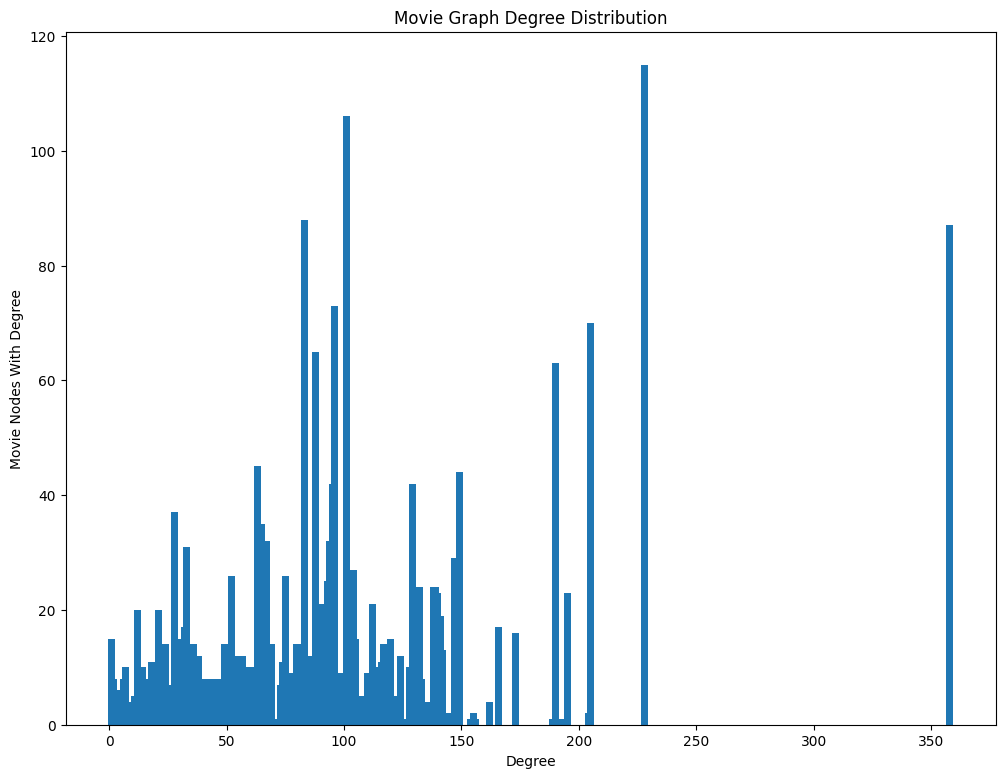

In [187]:
graph_data_file = "./graphs/movie_graph-JACCARD-60.pkl"
LOAD_GRAPH = True

if LOAD_GRAPH:
    movie_graph = Graph(0, [])
    movie_graph.load_graph(graph_data_file)
# movie_graph.print_neighbor_sets()

# Plot degree distribution for insight into graph connections
degree_dist = get_degree_distribution(movie_graph)
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
ax.bar(degree_dist.keys(), degree_dist.values(), width=3)
ax.set_xlabel("Degree")
ax.set_ylabel("Movie Nodes With Degree")
ax.set_title("Movie Graph Degree Distribution");